# Assignment 1: Dataset Selection and Profiling

**Dataset:** Titanic Passenger Manifest (Kaggle "Titanic - Machine Learning from Disaster" training set)

**Source:** Originally compiled by Encyclopedia Titanica; distributed via Kaggle (https://www.kaggle.com/c/titanic/data) and mirrored publicly at https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv

**License:** Released by Kaggle for open educational/competition use (public-domain historical passenger records; Kaggle competition data terms permit educational reuse).

This notebook loads the dataset, profiles it, builds a variable dictionary, demonstrates a misleading-type statistic, and produces the required frequency table, bar chart, dotplot/histogram.

## 1. Load the dataset and inspect basic structure

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv('titanic.csv')
print("Shape (rows, columns):", df.shape)
print("Size (total elements):", df.size)


Shape (rows, columns): (891, 12)
Size (total elements): 10692


In [1]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [1]:
df.head(10)

   PassengerId  Survived  Pclass                                                 Name     Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked
0            1         0       3                              Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500   NaN        S
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.0      1      0          PC 17599  71.2833   C85        C
2            3         1       3                               Heikkinen, Miss. Laina  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S
3            4         1       1         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0            113803  53.1000  C123        S
4            5         0       3                             Allen, Mr. William Henry    male  35.0      0      0            373450   8.0500   NaN        S
5            6         0       3                                

In [ ]:
df.tail(7)

     PassengerId  Survived  Pclass                                      Name     Sex   Age  SibSp  Parch           Ticket    Fare Cabin Embarked
884          885         0       3                    Sutehall, Mr. Henry Jr    male  25.0      0      0  SOTON/OQ 392076   7.050   NaN        S
885          886         0       3      Rice, Mrs. William (Margaret Norton)  female  39.0      0      5           382652  29.125   NaN        Q
886          887         0       2                     Montvila, Rev. Juozas    male  27.0      0      0           211536  13.000   NaN        S
887          888         1       1              Graham, Miss. Margaret Edith  female  19.0      0      0           112053  30.000   B42        S
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"  female   NaN      1      2       W./C. 6607  23.450   NaN        S
889          890         1       1                     Behr, Mr. Karl Howell    male  26.0      0      0           111369  30.000 

In [1]:
df.describe()

       PassengerId    Survived      Pclass         Age       SibSp       Parch        Fare
count   891.000000  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean    446.000000    0.382716    2.308642   29.699118    0.523008    0.381594   32.204208
std     257.353842    0.486323    0.836071   14.526497    1.102743    0.806057   49.693429
min       1.000000    0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%     223.500000    0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%     446.000000    0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%     668.500000    1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max     891.000000    1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [1]:
df.describe(include='all')

        PassengerId    Survived      Pclass                     Name   Sex         Age       SibSp       Parch  Ticket        Fare Cabin Embarked
count    891.000000  891.000000  891.000000                      891   891  714.000000  891.000000  891.000000     891  891.000000   204      889
unique          NaN         NaN         NaN                      891     2         NaN         NaN         NaN     681         NaN   147        3
top             NaN         NaN         NaN  Braund, Mr. Owen Harris  male         NaN         NaN         NaN  347082         NaN    G6        S
freq            NaN         NaN         NaN                        1   577         NaN         NaN         NaN       7         NaN     4      644
mean     446.000000    0.382716    2.308642                      NaN   NaN   29.699118    0.523008    0.381594     NaN   32.204208   NaN      NaN
std      257.353842    0.486323    0.836071                      NaN   NaN   14.526497    1.102743    0.806057     NaN   49.

In [1]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 2. Missing values per column

In [1]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## 3. Misleading variable type demonstration

`Pclass` (ticket class) is stored as an `int64`, which invites pandas to compute a numeric mean — but 1st/2nd/3rd class are ranked *categories*, not a measured quantity, so their average is meaningless.

In [1]:
meaningless_mean = df['Pclass'].mean()
print("Meaningless mean of Pclass:", round(meaningless_mean, 3))

correct_freq = df['Pclass'].value_counts().sort_index()
correct_pct = (df['Pclass'].value_counts(normalize=True).sort_index()*100).round(1)
print("\nCorrect summary: frequency of each class")
print(correct_freq)
print("\nPercentages:")
print(correct_pct)

Meaningless mean of Pclass: 2.309

Correct summary: frequency of each class
Pclass
1    216
2    184
3    491
Name: count, dtype: int64

Percentages:
Pclass
1    24.2
2    20.7
3    55.1
Name: proportion, dtype: float64


## 4. Frequency table for a categorical variable: `Embarked`

In [1]:
freq_embarked = df['Embarked'].value_counts(dropna=False)
rel_embarked = df['Embarked'].value_counts(normalize=True, dropna=False).round(4)
freq_table = pd.DataFrame({'Frequency': freq_embarked, 'Relative Frequency': rel_embarked})
freq_table

          Frequency  Relative Frequency
Embarked                               
S               644              0.7228
C               168              0.1886
Q                77              0.0864
NaN               2              0.0022


## 5. Bar chart of `Embarked`

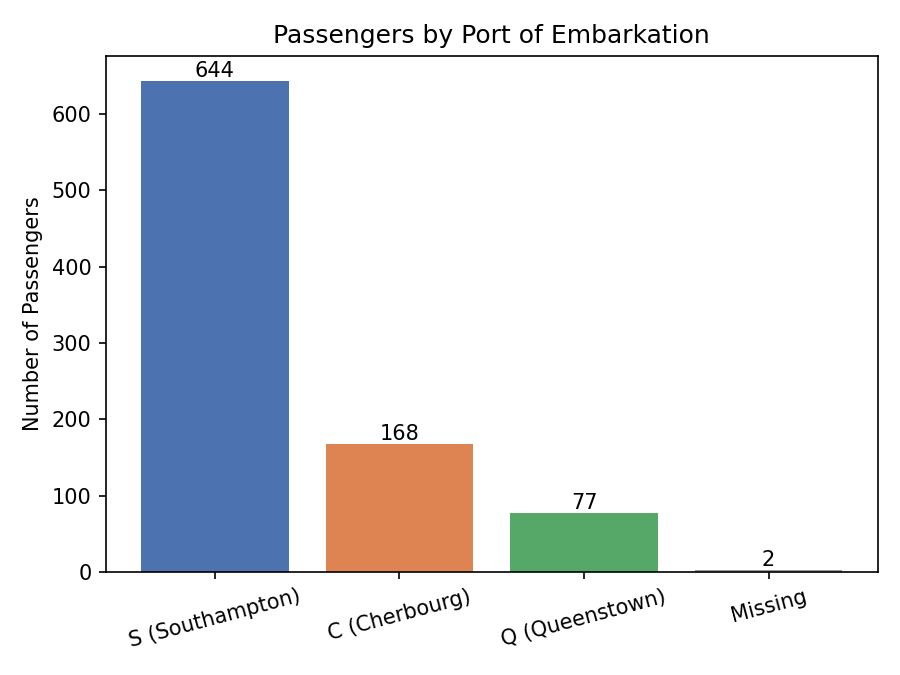

In [1]:
labels = ['S (Southampton)','C (Cherbourg)','Q (Queenstown)','Missing']
counts = [df['Embarked'].value_counts().get('S',0),
          df['Embarked'].value_counts().get('C',0),
          df['Embarked'].value_counts().get('Q',0),
          df['Embarked'].isna().sum()]
fig, ax = plt.subplots(figsize=(6,4.5))
ax.bar(labels, counts, color=['#4C72B0','#DD8452','#55A868','#999999'])
ax.set_title('Passengers by Port of Embarkation')
ax.set_ylabel('Number of Passengers')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 6. Histogram of a numerical variable: `Age`

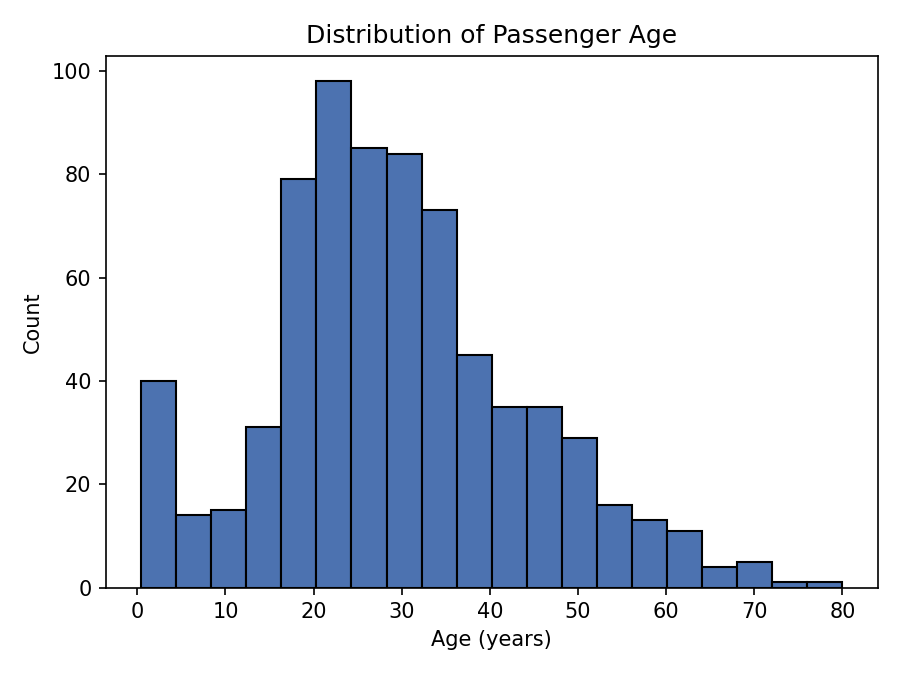

In [1]:
fig, ax = plt.subplots(figsize=(6,4.5))
ax.hist(df['Age'].dropna(), bins=20, color='#4C72B0', edgecolor='black')
ax.set_title('Distribution of Passenger Age')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 7. Dotplot of a numerical variable: `Fare`

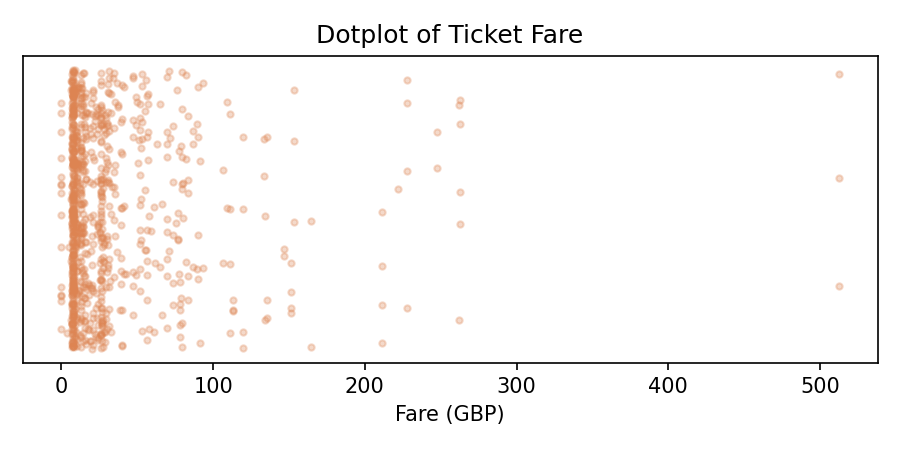

In [1]:
fig, ax = plt.subplots(figsize=(6,3))
sample = df['Fare'].dropna()
jitter = np.random.uniform(-0.05, 0.05, size=len(sample))
ax.plot(sample, jitter, '.', alpha=0.3, color='#DD8452')
ax.set_yticks([])
ax.set_xlabel('Fare (GBP)')
ax.set_title('Dotplot of Ticket Fare')
plt.tight_layout()
plt.show()

## 8. Survival rates by Sex and Pclass (context for later analysis)

In [1]:
print(df.groupby('Sex')['Survived'].mean())
print()
print(df.groupby('Pclass')['Survived'].mean())

Sex
female    0.738854
male      0.188908
Name: Survived, dtype: float64

Pclass
1    0.629630
2    0.472826
3    0.240326
Name: Survived, dtype: float64


## 9. Variable dictionary

See report (Section 3) for the full table with type classification, pandas dtype, missing-value counts, and variable descriptions for all 12 columns.